# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

trigger_create_cross_section = True

Setting Backend To: AvailableBackends.numpy


# Model Parameters

In [2]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Plutonite dip angle
plutonite_dip_angle = 70 # 70

# Importing Plutonic Model

In [3]:
# --- Load full model ---
with open("geomodel.pkl", "rb") as f:
    plutonite_geo_model = pickle.load(f)

# Forward Modelling Magnetics

Setting Measurement Grid and Determine which Voxels to use

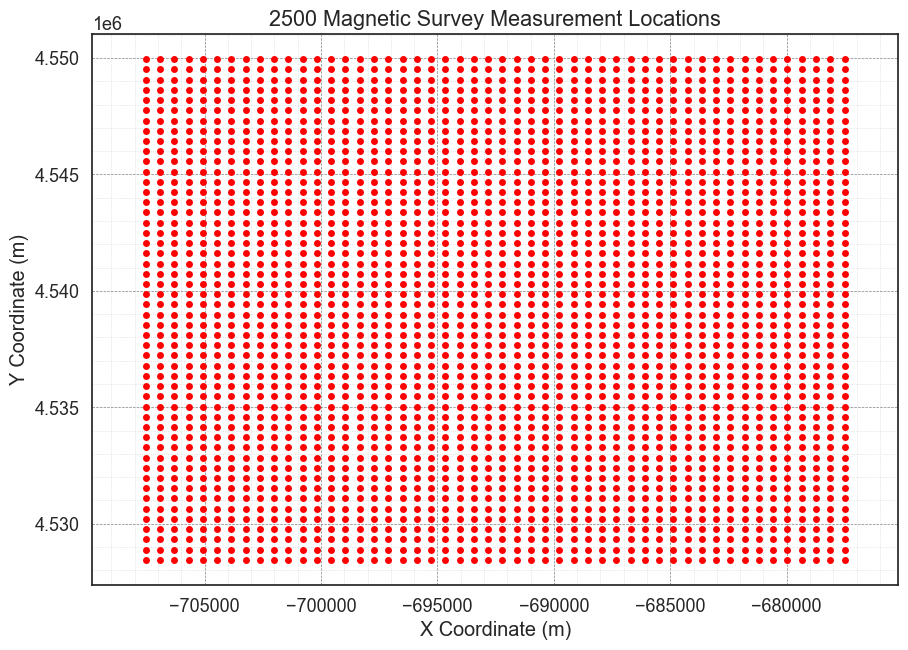

In [68]:
# Creating measurement devices for magnetic survey - using same grid as gravity
mag_res = 50
X_mag = np.linspace(min_x, max_x, mag_res)
Y_mag = np.linspace(min_y, max_y, mag_res)
Z_mag = max_z
xyz_mag = np.meshgrid(X_mag, Y_mag, Z_mag)
xy_ravel_mag = np.vstack(list(map(np.ravel, xyz_mag))).T

plt.plot(xy_ravel_mag[:,0], xy_ravel_mag[:,1], 'o', color='red', markersize=5)
plt.grid(which='major', color='grey', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(which='minor', color='lightgrey', linestyle=':', linewidth=0.5)
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')
plt.title(f'{len(xy_ravel_mag)} Magnetic Survey Measurement Locations')
plt.axis('equal')
plt.show()

# # Creating centred grids around the measurement devices for magnetic calculation
# gp.set_centered_grid(
#     grid=plutonite_geo_model.grid,
#     centers=xy_ravel_mag,
#     resolution=np.array([10, 10, 15]),
#     radius=np.array([1000, 1000, 1000])
# )

# plutonite_geo_model.grid.centered_grid.kernel_grid_centers;

Assigning Susceptibility Values

In [54]:
# Assign magnetic susceptibilities to voxels

# 1. Get the formation IDs for the model
plutonite_lith_block = plutonite_geo_model.solutions.raw_arrays.lith_block
plutonite_lith_block_reshaped = plutonite_lith_block.reshape(64,64,64)

# 2. Get the coordinates of these voxels
voxel_coords = plutonite_geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

# 3. Flip Y coordinate
y_min, y_max = np.min(voxel_coords[:, 1]), np.max(voxel_coords[:, 1])
voxel_coords_flipped = voxel_coords.copy()
voxel_coords_flipped[:, 1] = y_max - (voxel_coords[:, 1] - y_min)

# 2. Identify the formation ID of the Plutonite
plutonite_id = 1

# 3. Create a boolean mask for plutonite voxels
plutonite_mask = plutonite_lith_block_reshaped == plutonite_id

# 4. Create a susceptibility array
susceptibility_array = np.full(plutonite_lith_block_reshaped.shape, 0.01)  # Default susceptibility for non-plutonite voxels
susceptibility_array[plutonite_mask] = 0.05  # Higher susceptibility for plutonite voxels
susceptibility_array_flat = susceptibility_array.flatten()

print(f"Susceptibility array shape: {susceptibility_array_flat.shape}")
print(f"Number of plutonite voxels: {np.sum(plutonite_mask)}")
print(f"Susceptibility range: {np.min(susceptibility_array_flat):.3f} to {np.max(susceptibility_array_flat):.3f}")

# Find which formations are present in each voxel of the geological model
# 1 = Plutonites
# 2 = Basement

Susceptibility array shape: (262144,)
Number of plutonite voxels: 135445
Susceptibility range: 0.010 to 0.050


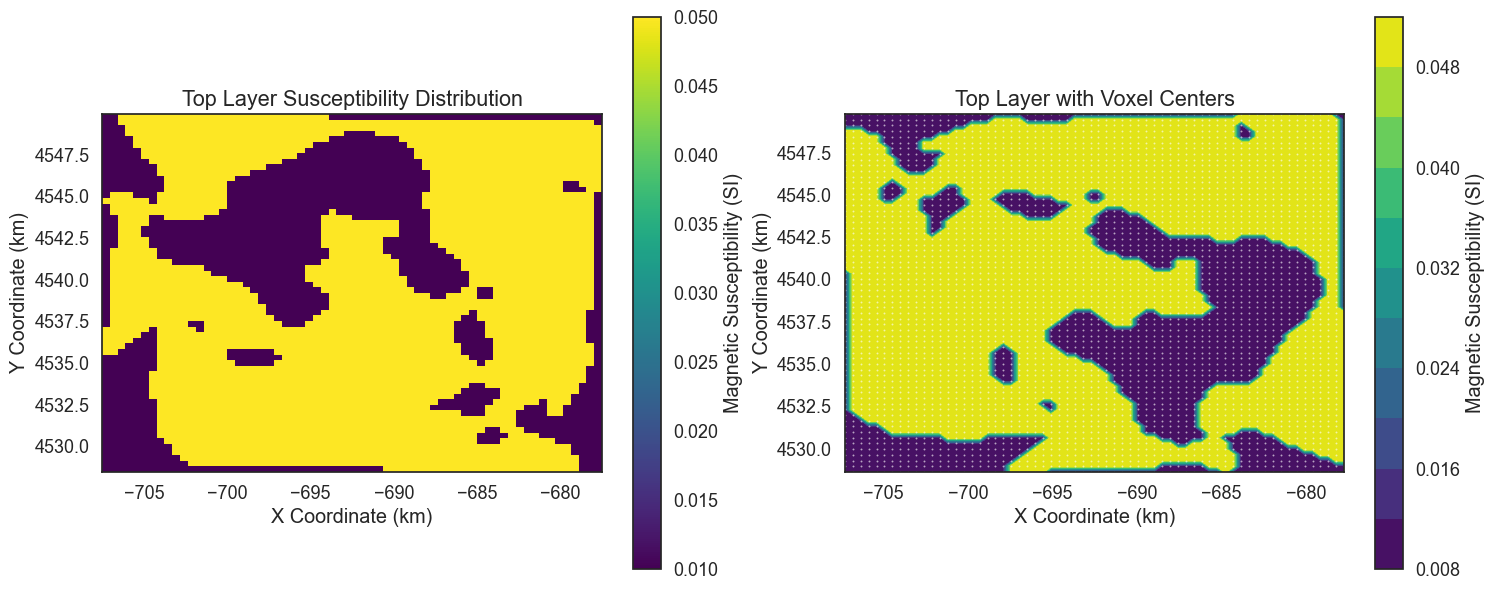

Top layer susceptibility statistics:
Shape: (64, 64)
Min: 0.0100
Max: 0.0500
Mean: 0.0377
Unique values: [0.01 0.05]


In [55]:
# Extract top layer voxel coordinates and susceptibility values
# Use flipped voxel coordinates for proper orientation
voxel_coords_flipped_reshaped = voxel_coords_flipped.reshape(64, 64, 64, 3)
top_layer_coords = voxel_coords_flipped_reshaped[:, :, -1, :]  # Top layer (highest z)
top_layer_susceptibility = susceptibility_array[:, :, -1]  # Top layer susceptibility

# Extract X and Y coordinates for plotting
x_top = top_layer_coords[:, :, 0]
y_top = top_layer_coords[:, :, 1]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Susceptibility map
im1 = ax1.imshow(top_layer_susceptibility, extent=[min_x/1000, max_x/1000, min_y/1000, max_y/1000], 
                 cmap='viridis', origin='lower', interpolation='nearest')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Magnetic Susceptibility (SI)')
ax1.set_xlabel('X Coordinate (km)')
ax1.set_ylabel('Y Coordinate (km)')
ax1.set_title('Top Layer Susceptibility Distribution')
ax1.set_aspect('equal')

# Plot 2: Contour plot with voxel centers
contour = ax2.contourf(x_top/1000, y_top/1000, top_layer_susceptibility, levels=10, cmap='viridis')
ax2.scatter(x_top.flatten()/1000, y_top.flatten()/1000, c='white', s=1, alpha=0.5)
cbar2 = plt.colorbar(contour, ax=ax2)
cbar2.set_label('Magnetic Susceptibility (SI)')
ax2.set_xlabel('X Coordinate (km)')
ax2.set_ylabel('Y Coordinate (km)')
ax2.set_title('Top Layer with Voxel Centers')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

# Print statistics
print(f"Top layer susceptibility statistics:")
print(f"Shape: {top_layer_susceptibility.shape}")
print(f"Min: {np.min(top_layer_susceptibility):.4f}")
print(f"Max: {np.max(top_layer_susceptibility):.4f}")
print(f"Mean: {np.mean(top_layer_susceptibility):.4f}")
print(f"Unique values: {np.unique(top_layer_susceptibility)}")

Forward Modelling

In [56]:
np.save("your_susceptibility.npy", susceptibility_array)

In [69]:
voxel_centers = voxel_coords_flipped
voxel_sizes = np.array([plutonite_geo_model.grid.regular_grid.dx,
                         plutonite_geo_model.grid.regular_grid.dy,
                         plutonite_geo_model.grid.regular_grid.dz])
measurement_points = xy_ravel_mag

In [76]:
from forward_modelling_magnetics_python import NumpyMagneticsForwardModeling


# Method 1: Manual cutoff
mag_engine = NumpyMagneticsForwardModeling(cutoff_distance=5000.0)
mag_engine.set_magnetic_parameters(B_ext=50e-6, incl=60.0, decl=0.43)
results = mag_engine.load_and_process_model(
    "your_susceptibility.npy", 
    voxel_centers, 
    voxel_sizes, 
    measurement_points
)

Loading susceptibility model from your_susceptibility.npy
Loaded susceptibility model with shape: (64, 64, 64)
Processing 2500 measurement points with 262144 voxels
Computing volume integrals for 262144 voxels and 2500 measurements...
Using distance cutoff: 5.0 km
Pre-computing active voxels within cutoff distance...
  Measurement point 1: 7905/262144 active voxels (3.0%)
Total active voxel-measurement pairs: 64765588 (vs 655360000 without cutoff)
Computational reduction: 90.1%
Processing measurements 1 to 1000 of 2500
Volume integrals computed in 179.47 seconds
Computing magnetic forward modeling...
Using compact format with distance cutoff...
Processing 64765588 active voxel-measurement pairs
Magnetic anomaly computed: -6761.31 to 6883.67 nT
Magnetic forward modeling completed in 156.20 seconds


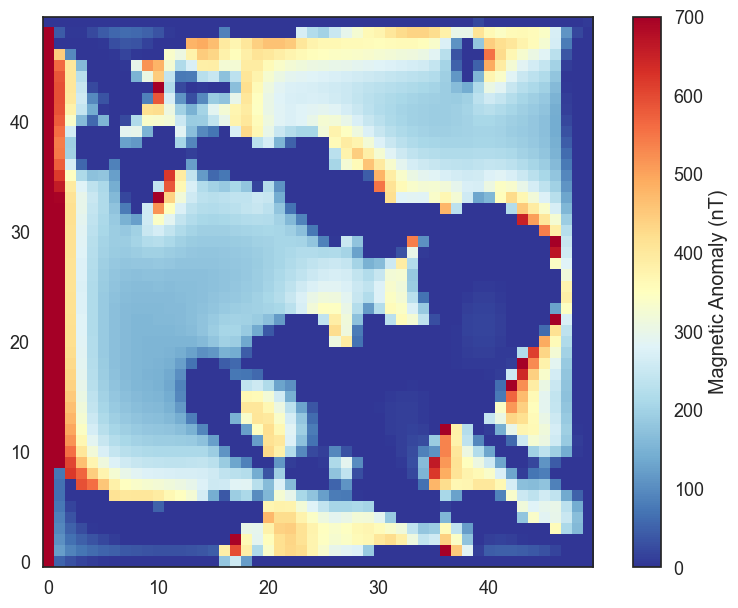

In [77]:
plt.imshow(results.reshape(mag_res, mag_res).clip(0, 700), cmap='RdYlBu_r', origin='lower')
plt.colorbar(label='Magnetic Anomaly (nT)')

Text(0.5, 1.0, 'Magnetic Anomaly (Trimmed)')

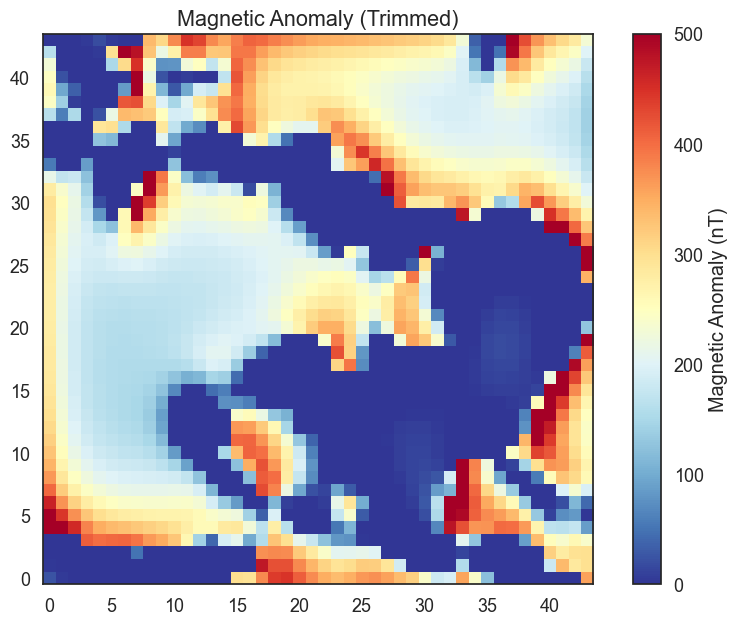

In [78]:

# Use this (removes 1 pixel from each edge):
trim = 3
results_2d = results.reshape(mag_res, mag_res)[trim:-trim, trim:-trim]
plt.imshow(results_2d.clip(0, 500), cmap='RdYlBu_r', origin='lower')
plt.colorbar(label='Magnetic Anomaly (nT)')
plt.title(f'Magnetic Anomaly (Trimmed)')

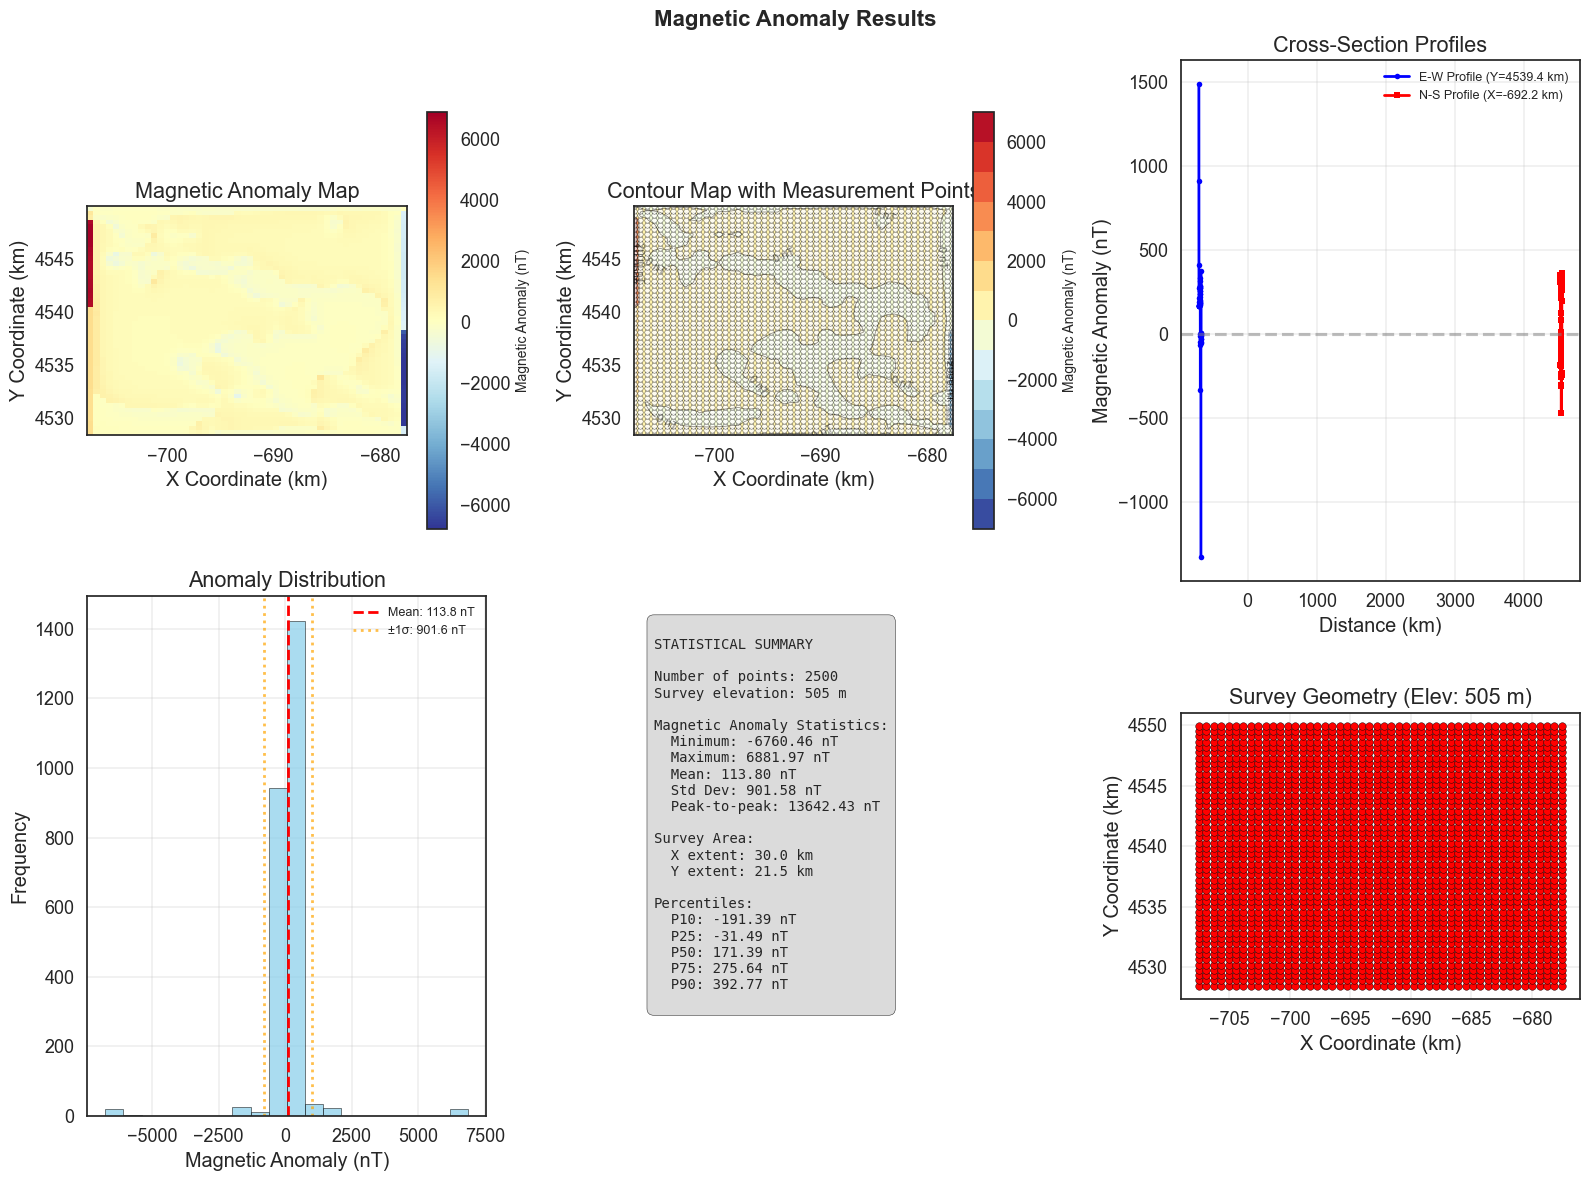


VISUALIZATION SUMMARY
Figure type: Regular grid
Measurement points: 2500
Anomaly range: -6760.46 to 6881.97 nT
Survey area: 30.0 × 21.5 km
✅ Comprehensive magnetic anomaly visualization complete!


In [73]:
from forward_modelling_magnetics_python import visualize_magnetic_results
visualize_magnetic_results(results, measurement_points)
